<a href="https://colab.research.google.com/github/rijosudu123/ict-assessment/blob/main/CASE_STUDY_OF_UNSUPERVISED_LEARNING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

In [2]:
adult = pd.read_csv("/content/adult_dataset.csv")
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [3]:
adult.shape

(48842, 15)

In [4]:
adult['education'].value_counts()

,count
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [5]:
adult['education-num'].value_counts()

,count
education-num,
9,15784
10,10878
13,8025
14,2657
11,2061
7,1812
12,1601
6,1389
4,955


In [6]:
adult.drop(columns=['education','income'],inplace=True)

In [7]:
columns = ['race']
for i in  columns:
  adult.drop(columns=i,inplace=True)


In [8]:
adult.head()

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40.0,NaN
1,50.0,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13.0,United-States
2,38.0,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40.0,United-States
3,53.0,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40.0,United-States
4,28.0,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40.0,Cuba


In [9]:
adult.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education-num,0
marital-status,0
occupation,3357
relationship,0
sex,0
capital-gain,0
capital-loss,0


In [10]:
adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education-num   48842 non-null  int64  
 4   marital-status  48842 non-null  object 
 5   occupation      45485 non-null  object 
 6   relationship    48842 non-null  object 
 7   sex             48842 non-null  object 
 8   capital-gain    48842 non-null  int64  
 9   capital-loss    48842 non-null  int64  
 10  hours-per-week  46400 non-null  float64
 11  native-country  46137 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 4.5+ MB


In [11]:
adult['age']=adult['age'].fillna(adult['age'].mean())

In [12]:
columns = ['workclass','occupation','native-country']
for i in columns:
  adult[i]=adult[i].fillna(adult[i].mode()[0])

In [13]:
adult['hours-per-week']=adult['hours-per-week'].fillna(adult['hours-per-week'].mean())

In [14]:
adult.head()

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,State-gov,77516,13,Never-married,Adm-clerical,Not-in-family,Male,2174,0,40.0,United-States
1,50.0,Self-emp-not-inc,83311,13,Married-civ-spouse,Exec-managerial,Husband,Male,0,0,13.0,United-States
2,38.0,Private,215646,9,Divorced,Handlers-cleaners,Not-in-family,Male,0,0,40.0,United-States
3,53.0,Private,234721,7,Married-civ-spouse,Handlers-cleaners,Husband,Male,0,0,40.0,United-States
4,28.0,Private,338409,13,Married-civ-spouse,Prof-specialty,Wife,Female,0,0,40.0,Cuba


In [15]:
adult.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education-num,0
marital-status,0
occupation,0
relationship,0
sex,0
capital-gain,0
capital-loss,0


In [16]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [17]:
label_enc = LabelEncoder()
columns = ['workclass','marital-status','occupation','relationship','sex','native-country']
for i in columns:
  adult[i] = label_enc.fit_transform(adult[i])

In [18]:
adult

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39.0,7,77516,13,4,1,1,1,2174,0,40.0,39
1,50.0,6,83311,13,2,4,0,1,0,0,13.0,39
2,38.0,4,215646,9,0,6,1,1,0,0,40.0,39
3,53.0,4,234721,7,2,6,0,1,0,0,40.0,39
4,28.0,4,338409,13,2,10,5,0,0,0,40.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,4,215419,13,0,10,1,0,0,0,36.0,39
48838,64.0,4,321403,9,6,10,2,1,0,0,40.0,39
48839,38.0,4,374983,13,2,10,0,1,0,0,50.0,39
48840,44.0,4,83891,13,0,1,3,1,5455,0,40.0,39


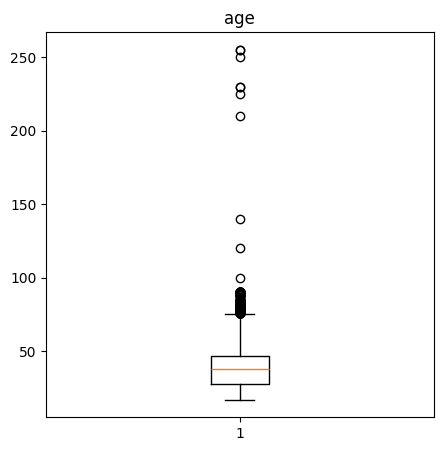

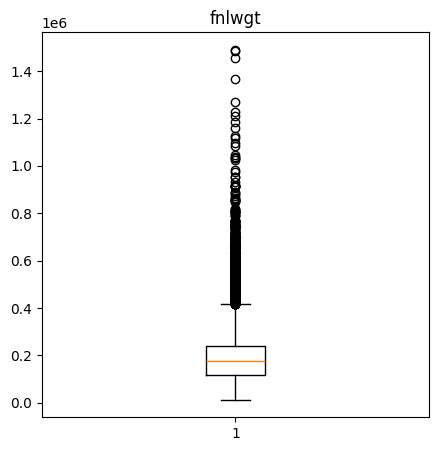

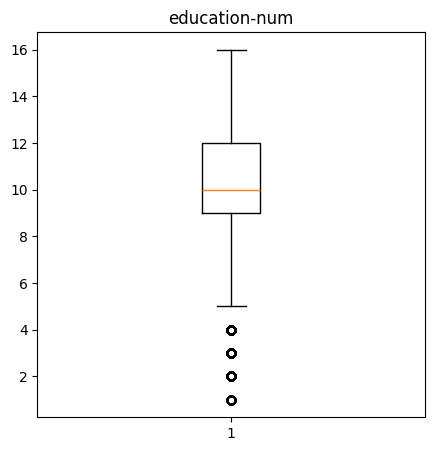

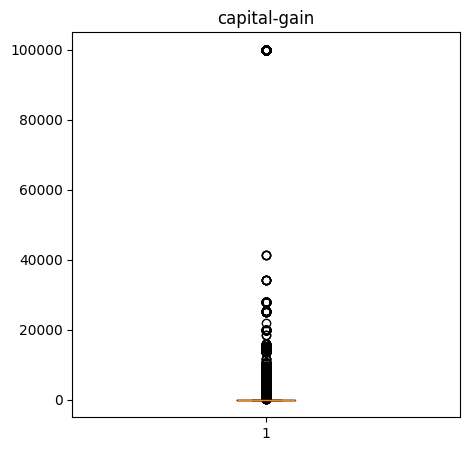

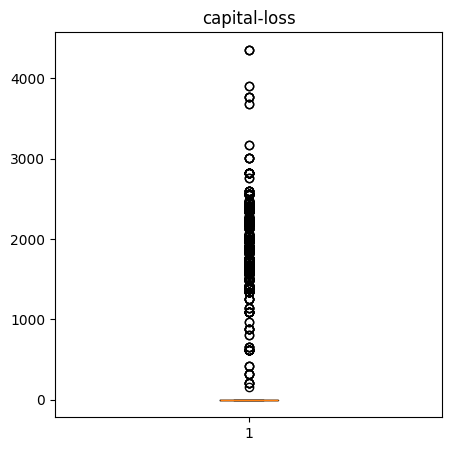

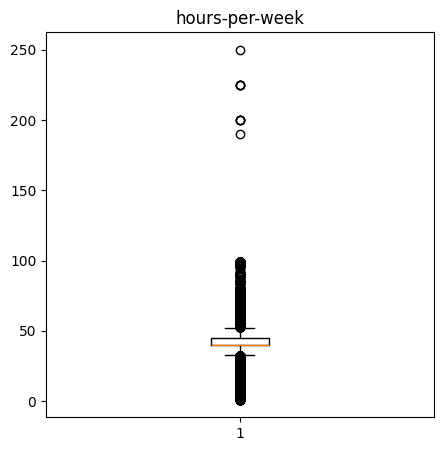

In [19]:
columns = ['age','fnlwgt','education-num','capital-gain','capital-loss','hours-per-week']
for i in columns:
  plt.figure(figsize = (5,5))
  plt.boxplot(adult[i])
  plt.title(i)
  plt.show()

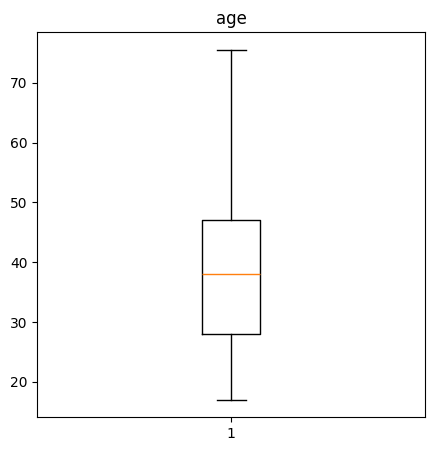

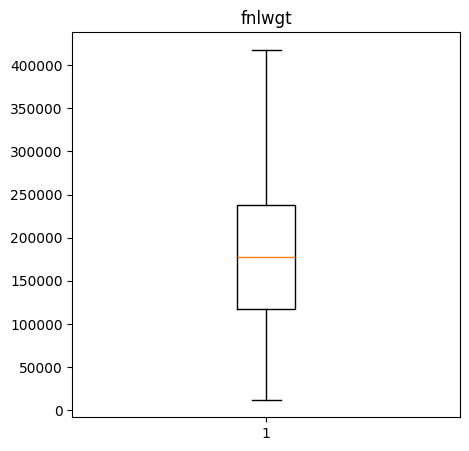

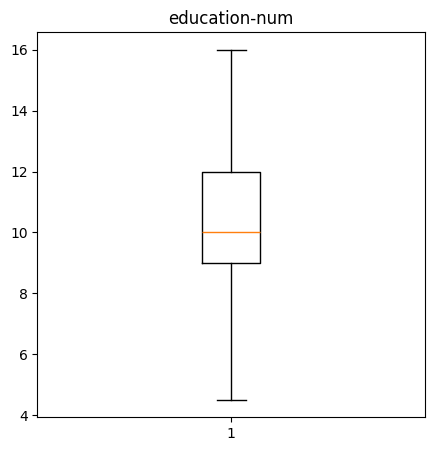

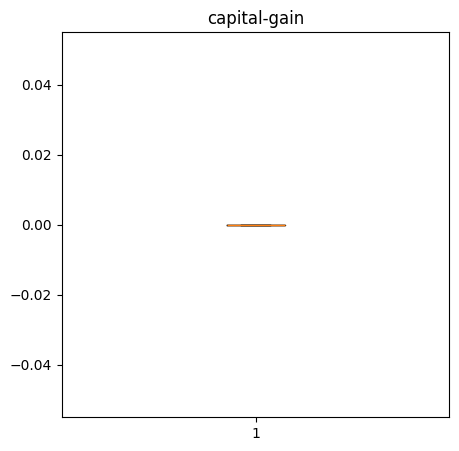

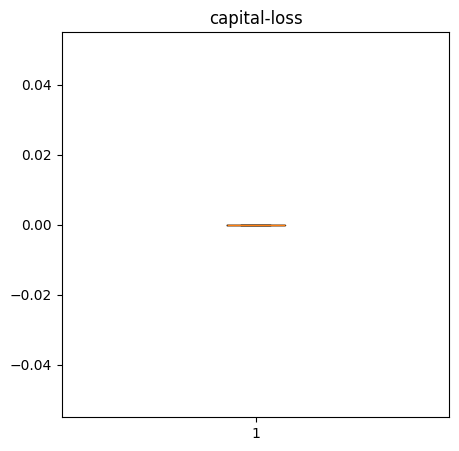

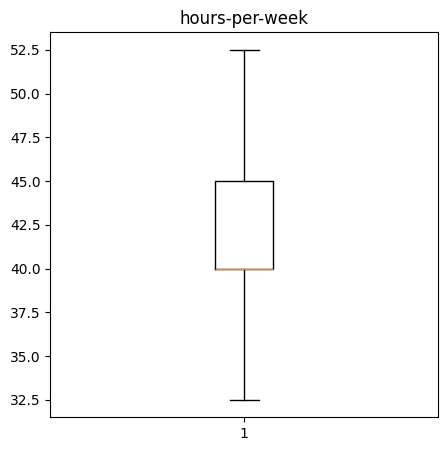

In [20]:
for i in columns:
  q1 = adult[i].quantile(0.25)
  q3 = adult[i].quantile(0.75)
  iqr=q3-q1
  lower = q1-1.5*iqr
  upper = q3+1.5*iqr
  adult[i] = adult[i].clip(lower=lower,upper=upper)
  plt.figure(figsize=(5,5))
  plt.boxplot(adult[i])
  plt.title(i)

In [21]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [22]:
standard_scl = StandardScaler()
columns = ['age','fnlwgt','capital-gain','capital-loss','hours-per-week','native-country','education-num']
for i in columns:
  adult[i] = standard_scl.fit_transform(adult[[i]])

In [23]:
import seaborn as sns

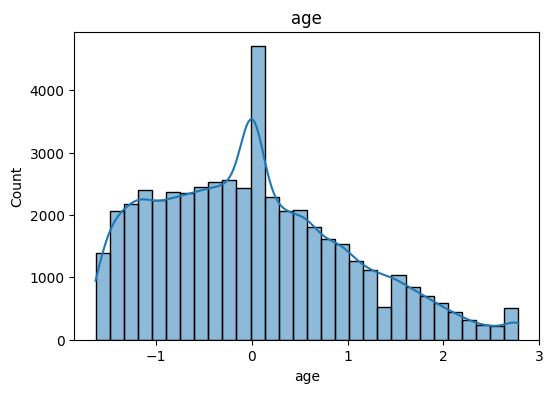

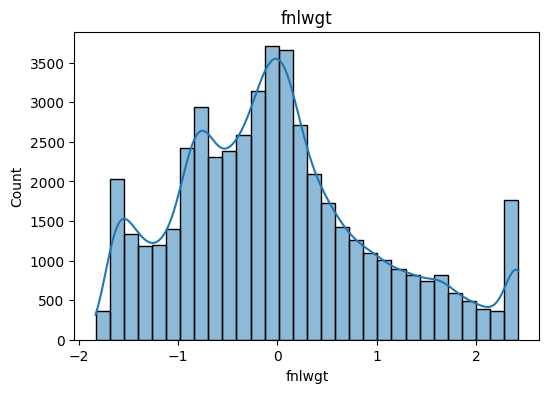

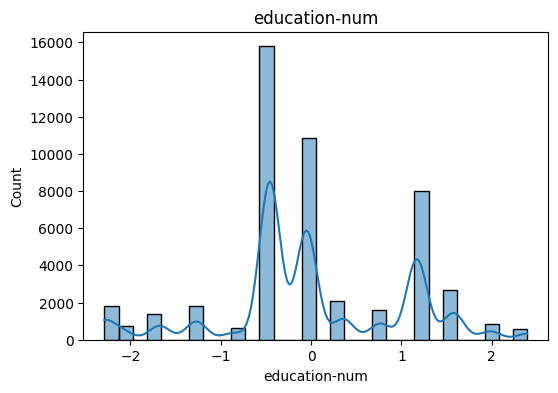

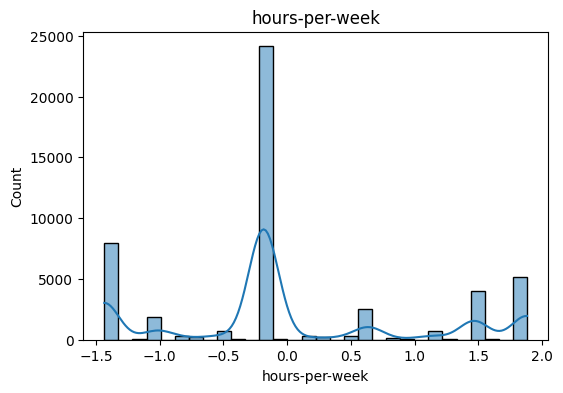

In [24]:
columns_hist = ['age','fnlwgt','education-num','hours-per-week']
for h in columns_hist:
  plt.figure(figsize = (6,4))
  sns.histplot(adult[h], kde = True,bins = 30)
  plt.title(h)
  plt.show()

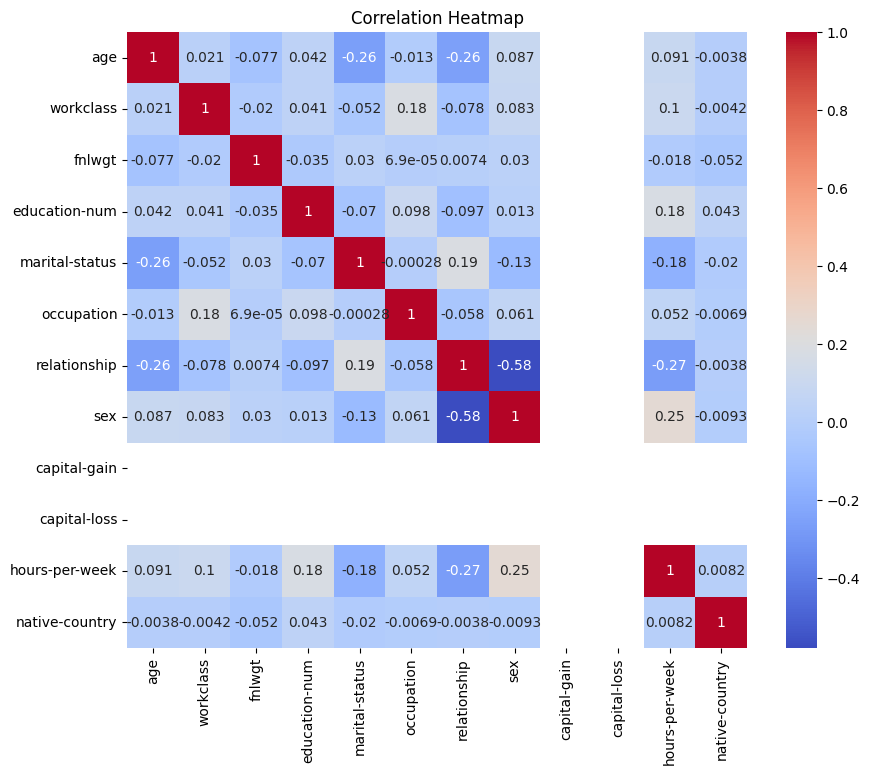

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(adult.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#PCA

In [26]:
from sklearn.decomposition import PCA

In [27]:
pca_model = PCA(n_components = 9)
adult= pca_model.fit_transform(adult)

In [28]:
explained_variance = pca_model.explained_variance_ratio_
explained_variance

array([0.59144938, 0.11411677, 0.06857331, 0.05813239, 0.03819946,
       0.03566857, 0.03349207, 0.02886293, 0.02670164])

In [29]:
sum(explained_variance)

np.float64(0.9951965442871148)

In [30]:
adult_pca = pd.DataFrame(adult,columns = ["PC1","PC2","PC3","PC4","PC5","PC6","PC7","PC8","PC9"])

In [31]:
adult_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-5.679411,-0.353926,1.473101,3.443816,1.305089,-0.441653,-0.538605,0.458580,-0.814450
1,-2.743112,-1.839970,0.269468,1.872192,0.602401,-1.216589,-0.308507,1.151092,-1.739126
2,-0.926935,-1.709540,-1.803915,-0.158714,-0.667955,-0.103893,0.760132,-0.399687,-0.395616
3,-0.926125,-1.579575,0.304662,-0.234850,-1.148678,-0.899573,0.678127,0.381291,0.610000
4,2.987864,2.740102,-2.439858,0.300061,-2.215380,3.120798,-3.166731,0.395747,-0.682514
...,...,...,...,...,...,...,...,...,...
48837,3.084534,-1.446420,-2.004161,-0.422754,0.095695,0.315354,0.460613,0.590151,-1.489541
48838,3.016672,1.936496,2.284667,-0.021705,-0.511059,-0.234538,0.233771,2.288604,1.810655
48839,3.151804,-1.736034,0.434335,-0.299964,0.067714,2.250812,0.884481,0.418386,0.445223
48840,-5.926800,-0.710586,-2.958974,0.446365,1.251884,-0.084399,-0.540464,0.216633,-0.712851


#KMEAN

In [32]:
from sklearn.cluster import KMeans

In [33]:
wcss_list=[]
for i in range(1,11):
      kmeans = KMeans (n_clusters = i,init='k-means++',random_state = 42)
      kmeans.fit(adult_pca)

      wcss_list.append(kmeans.inertia_)

wcss_list

[1394473.054971149,
 748500.394185151,
 648641.899380866,
 601114.9520998043,
 537454.504675259,
 510067.4708246314,
 479107.8655929433,
 462198.32947289274,
 447076.83850739105,
 415242.37168980076]

Text(0, 0.5, 'wcss')

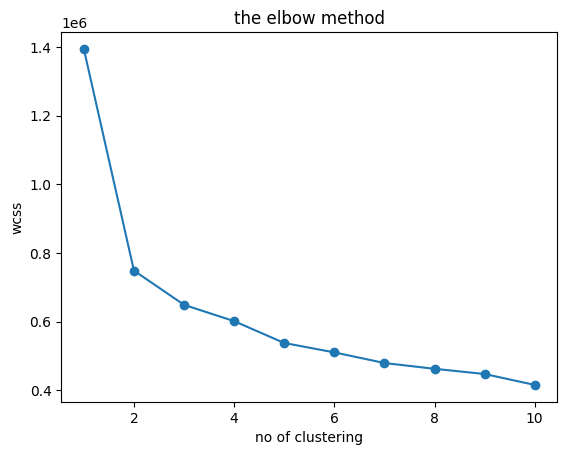

In [34]:
plt.plot(range(1,11),wcss_list,marker = 'o')
plt.title('the elbow method')
plt.xlabel('no of clustering')
plt.ylabel('wcss')

In [35]:
kmeans_model = KMeans(n_clusters = 5, init = 'k-means++' ,random_state = 42,n_init=10)
y_predict = kmeans_model.fit_predict(adult_pca)
y_predict

array([0, 0, 4, ..., 3, 2, 0], dtype=int32)

In [36]:
adult_pca['kmeans_cluster'] = y_predict
adult_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,kmeans_cluster
0,-5.679411,-0.353926,1.473101,3.443816,1.305089,-0.441653,-0.538605,0.458580,-0.814450,0
1,-2.743112,-1.839970,0.269468,1.872192,0.602401,-1.216589,-0.308507,1.151092,-1.739126,0
2,-0.926935,-1.709540,-1.803915,-0.158714,-0.667955,-0.103893,0.760132,-0.399687,-0.395616,4
3,-0.926125,-1.579575,0.304662,-0.234850,-1.148678,-0.899573,0.678127,0.381291,0.610000,4
4,2.987864,2.740102,-2.439858,0.300061,-2.215380,3.120798,-3.166731,0.395747,-0.682514,1


In [37]:
adult_pca['kmeans_cluster'].value_counts()

,count
kmeans_cluster,
0,12050
3,10274
4,9958
1,8800
2,7760


Text(0.5, 1.0, 'k-means_clustering on adult dataset (PCA)')

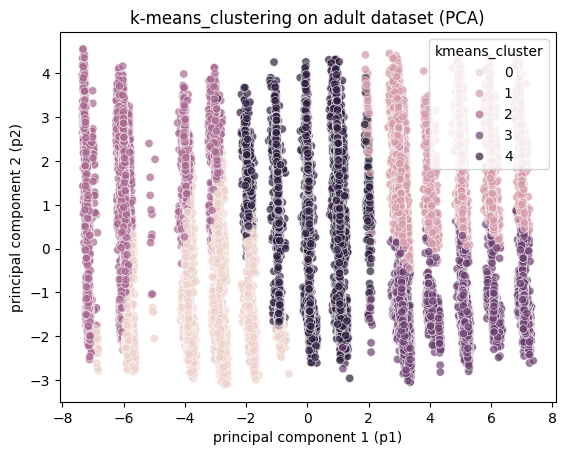

In [38]:
sns.scatterplot(x = 'PC1',
               y = 'PC2',
               data = adult_pca,
               hue = 'kmeans_cluster',
                alpha=0.7)
plt.xlabel('principal component 1 (p1)')
plt.ylabel('principal component 2 (p2)')
plt.title('k-means_clustering on adult dataset (PCA)')



#SILHOUETTE

In [39]:
from sklearn.metrics import silhouette_score

In [40]:
from sklearn.metrics import silhouette_score

for k in range(3,7):
    model = KMeans(
        n_clusters=k, init="k-means++", random_state=42, n_init=10
    )
    labels = model.fit_predict(adult_pca)
    score = silhouette_score(adult_pca, labels)
    print(f"Silhouette Score for k={k}: {score:.4f}")

Silhouette Score for k=3: 0.2759
Silhouette Score for k=4: 0.2674
Silhouette Score for k=5: 0.2676
Silhouette Score for k=6: 0.2664


#AGGLOMERATIVE CLUSTERING

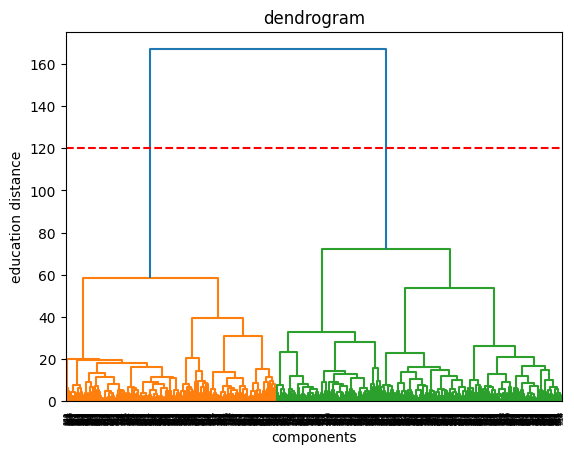

In [41]:
from scipy.cluster.hierarchy import dendrogram,linkage
np.random.seed(46)
sample_indices = np.random.choice(adult_pca.shape[0], size=1000, replace=False)
adult_samples = adult_pca.values[sample_indices]
mergings=(linkage(adult_samples,method='ward'))
dendrogram(mergings)
plt.title('dendrogram')
plt.xlabel('components')
plt.ylabel('education distance')
plt.axhline(y=120,color='r',linestyle='--')

In [42]:
from scipy.cluster.hierarchy import fcluster
agglo_cluster = fcluster(mergings,120,criterion='distance')
agglo_cluster

array([2, 1, 1, 2, 1, 1, 1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 1,
       1, 2, 1, 1, 1, 2, 2, 2, 1, 1, 2, 1, 2, 1, 1, 2, 1, 2, 2, 1, 2, 1,
       1, 2, 2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 1, 1,
       1, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 2, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 1, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2,
       2, 1, 1, 1, 2, 2, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2,
       1, 1, 1, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 2,
       1, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 2,
       2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 1, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 2,
       1, 2, 2, 1, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 2, 2, 1, 2, 2, 2, 2, 2,
       2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 1,

In [43]:
adult_samples_df = pd.DataFrame(
    adult_samples,
    columns=[f'p{i+1}' for i in range(adult_samples.shape[1])]
)
adult_samples_df['agglo_cluster'] = agglo_cluster
adult_samples_df.head()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,agglo_cluster
0,1.247484,0.134495,1.310250,2.883200,-0.919113,-0.001371,0.830875,1.169421,0.510061,4.0,2
1,-2.854609,-2.029118,0.341614,0.017825,0.771884,-0.000532,-0.255879,0.449401,0.128929,0.0,1
2,-1.801812,-1.813513,0.368872,1.768372,-1.835409,-0.775334,1.138675,0.580803,0.766133,0.0,1
3,3.165249,0.175121,1.246834,0.954298,1.290069,0.267059,-0.420408,0.394141,0.082932,1.0,2
4,-5.977897,2.206784,0.384309,0.788129,-0.298019,0.627341,-0.184484,-0.839301,-0.154904,2.0,1


In [44]:
adult_samples_df['agglo_cluster'].value_counts()

,count
agglo_cluster,
2,575
1,425


Text(0.5, 1.0, 'Agglomarative Clustering')

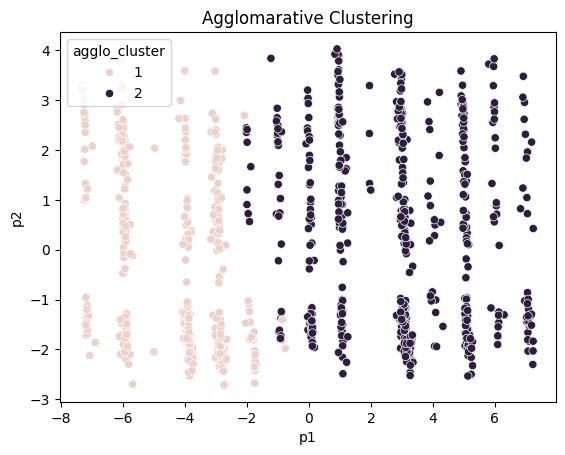

In [45]:
import seaborn as sns
sns.scatterplot(x = 'p1',
                y = 'p2',
                data = adult_samples_df,
                hue ='agglo_cluster')
plt.xlabel("p1")
plt.ylabel('p2')
plt.title('Agglomarative Clustering')